In [1]:
import pandas as pd
import numpy as np
import srtm
from pyproj import Transformer

In [2]:
FLIGHTLEVEL = 120

In [3]:
elevation_data = srtm.get_data()
transformer = Transformer.from_crs("epsg:4326", "epsg:4978", always_xy=True)

def clean_aviation_coord(coord_str):
    """
    Wandelt Koordinaten-Strings (DD.ddddN oder DDMMSS.ssE) in Decimal Degrees um.
    """
    if pd.isna(coord_str):
        return 0.0
    
    s = str(coord_str).upper().strip()
    multiplier = -1 if ('S' in s or 'W' in s) else 1
    
    # Nur Ziffern und Dezimalpunkt extrahieren
    digits_only = ''.join(c for c in s if c.isdigit() or c == '.')
    
    if not digits_only:
        return 0.0

    # LOGIK-CHECK: Wo sitzt der Dezimalpunkt?
    dot_pos = digits_only.find('.')
    
    # Wenn der Punkt an Index 2 oder 3 ist (z.B. 47.48 oder 008.55), ist es bereits Dezimal (Bild 1)
    if dot_pos != -1 and dot_pos <= 3:
        return float(digits_only) * multiplier
    
    # Ansonsten: DMS Format DDMMSS.ss (Bild 2)
    try:
        val = float(digits_only)
        seconds = val % 100
        minutes = (val // 100) % 100
        degrees = (val // 10000)
        
        dd = degrees + (minutes / 60) + (seconds / 3600)
        return dd * multiplier
    except Exception:
        return 0.0


def prepare_data(file_path, flight_level_ft, res_km=5.0):
    """
    Prepares DME data and creates a calculation grid.
    res_km: Resolution of the grid in kilometers.
    """
    df = pd.read_excel(file_path)
    
    # 1. Clean the coordinates
    df['LAT_CLEAN'] = df['LAT'].apply(clean_aviation_coord)
    df['LON_CLEAN'] = df['LON'].apply(clean_aviation_coord)
    
    # 2. Fetch Station Elevations & Convert to ECEF
    ecef_stations = []
    for _, row in df.iterrows():
        lat, lon = row['LAT_CLEAN'], row['LON_CLEAN']
        ground_alt = elevation_data.get_elevation(lat, lon) + 20 or 0.0
        x, y, z = transformer.transform(lon, lat, ground_alt)
        
        ecef_stations.append({
            'IDENT': row['IDENTIFIER'], 
            'TYPE': row['TYPE'],
            'lat': lat, 
            'lon': lon, 
            'alt': ground_alt,  # Add 100m to ensure we are above ground
            'x': x, 'y': y, 'z': z
        })
    
    # 3. Dynamic Grid Generation
    # Approximation: 1 degree Lat = 111km, 1 degree Lon at 47N = ~75km
    lat_step = res_km / 111.0
    lon_step = res_km / 75.0
    
    lat_range = np.arange(45.7, 47.9, lat_step) 
    lon_range = np.arange(5.8, 10.6, lon_step)
    
    actual_alt_m = (flight_level_ft * 100) * 0.3048 
    
    grid_points = []
    for lat in lat_range:
        for lon in lon_range:
            gx, gy, gz = transformer.transform(lon, lat, actual_alt_m)
            grid_points.append([gx, gy, gz, lat, lon])
            
    print(f"Grid generated with {len(grid_points)} cells (Resolution: {res_km}km)")
    return pd.DataFrame(ecef_stations), np.array(grid_points)

# Correct usage for FL100 (10,000 ft)
dme_ecef, grid_ecef = prepare_data("DME.xlsx", FLIGHTLEVEL, res_km=2.0)

Grid generated with 22140 cells (Resolution: 2.0km)


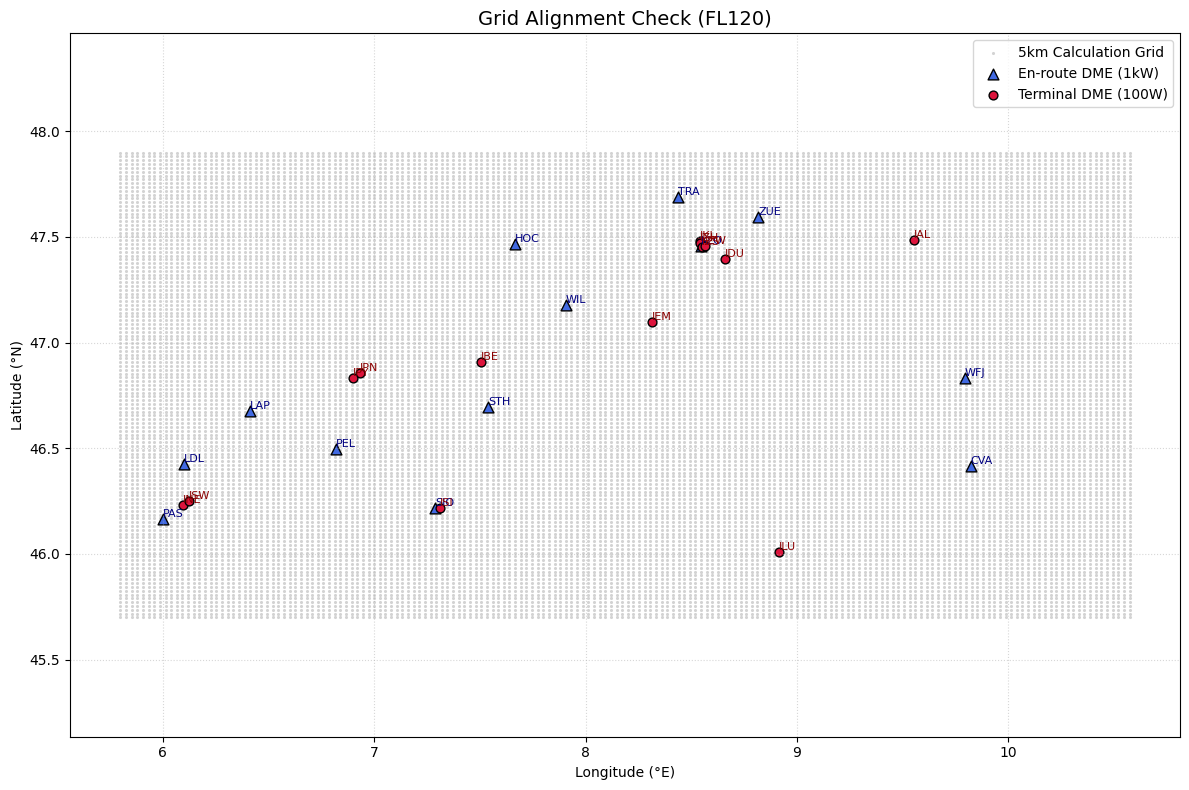

In [4]:
import matplotlib.pyplot as plt

def plot_sanity_check(dme_df, grid_points):
    plt.figure(figsize=(12, 8))
    
    # 1. Plot Grid Points (background)
    # grid_points[:, 4] is Longitude, grid_points[:, 3] is Latitude
    plt.scatter(grid_points[:, 4], grid_points[:, 3], s=1.5, c='lightgrey', label='5km Calculation Grid')
    
    # 2. Plot DME Stations by Type
    # Use lowercase 'type' if that's how it was stored in the dict
    enroute = dme_df[dme_df['TYPE'].str.lower() == 'enroute']
    terminal = dme_df[dme_df['TYPE'].str.lower() == 'terminal']
    
    plt.scatter(enroute['lon'], enroute['lat'], 
                c='royalblue', marker='^', s=60, label='En-route DME (1kW)', edgecolors='black')

    # Label each DME with its IDENT code
    for _, row in enroute.iterrows():
        plt.text(row['lon'], row['lat'], row['IDENT'], fontsize=8, color='navy',
                 ha='left', va='bottom')

    for _, row in terminal.iterrows():
        plt.text(row['lon'], row['lat'], row['IDENT'], fontsize=8, color='darkred',
                 ha='left', va='bottom')
    
    plt.scatter(terminal['lon'], terminal['lat'], 
                c='crimson', marker='o', s=40, label='Terminal DME (100W)', edgecolors='black')
    
    # 3. Aesthetics
    plt.title(f"Grid Alignment Check (FL{FLIGHTLEVEL})", fontsize=14)
    plt.xlabel("Longitude (°E)")
    plt.ylabel("Latitude (°N)")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.axis('equal') # Keep aspect ratio square-ish
    plt.tight_layout()
    plt.show()

# Run the check
plot_sanity_check(dme_ecef, grid_ecef)

In [5]:
import math

def calculate_max_radius(p_tx_watts, p_rx_min_dbm, freq_mhz=1000):
    """
    Calculates max radius in meters based on Free Space Path Loss.
    p_tx_watts: Power in Watts (e.g., 1000 for En-route)
    p_rx_min_dbm: Min threshold in dBm (e.g., -79)
    """
    # 1. Convert Transmit Power from Watts to dBm
    # P(dBm) = 10 * log10(P(W) * 1000)
    p_tx_dbm = 10 * math.log10(p_tx_watts * 1000)
    
    # 2. Maximum allowable Path Loss
    max_path_loss = p_tx_dbm - p_rx_min_dbm
    
    # 3. Solve FSPL for distance d (km)
    # FSPL = 20log10(d) + 20log10(f) + 32.44
    # log10(d) = (FSPL - 20log10(f) - 32.44) / 20
    log_d = (max_path_loss - 20 * math.log10(freq_mhz) - 32.44) / 20
    d_km = 10**log_d
    
    return d_km * 1000  # Convert to meters

# --- Configuration Section ---
P_TX_ENROUTE = 1000    # Watts
P_TX_TERMINAL = 100    # Watts
P_RX_THRESHOLD = -79   # dBm

R_MAX_ENROUTE = calculate_max_radius(P_TX_ENROUTE, P_RX_THRESHOLD)
R_MAX_TERMINAL = calculate_max_radius(P_TX_TERMINAL, P_RX_THRESHOLD)

print(f"Calculated R_max En-route: {R_MAX_ENROUTE/1000:.2f} km")
print(f"Calculated R_max Terminal: {R_MAX_TERMINAL/1000:.2f} km")

Calculated R_max En-route: 212.81 km
Calculated R_max Terminal: 67.30 km


In [6]:
import numpy as np
from pyproj import Transformer
import pandas as pd
from numba import njit, prange

inv_transformer = Transformer.from_crs("epsg:4978", "epsg:4326", always_xy=True)
EARTH_RADIUS = 6_371_000.0
R_EFF = EARTH_RADIUS * (4 / 3)  # k=4/3 effective radius for radio propagation


def ecef_to_lla_batch(pts: np.ndarray):
    return inv_transformer.transform(pts[:, 0], pts[:, 1], pts[:, 2])


# ── Earth bulge correction ────────────────────────────────────────────────────

@njit(cache=True)
def _earth_bulge(d_total: float, d_from_p1: float) -> float:
    """Radio-path bulge due to Earth curvature [m]. Add to terrain elevation."""
    d2 = d_total - d_from_p1
    return (d_from_p1 * d2) / (2.0 * R_EFF)


# ── DDA-style ray marcher with early exit ────────────────────────────────────

@njit(cache=True)
def _ray_march_check(
    ray_alts:     np.ndarray,   # (S,) interpolated ray altitude at each step
    ground_elevs: np.ndarray,   # (S,) terrain elevation at each step
    bulge_corrs:  np.ndarray,   # (S,) earth curvature correction
) -> tuple[bool, int]:
    """
    Walks the ray and exits immediately on first obstruction.
    Returns (is_clear, steps_taken) — steps_taken lets the caller
    know how much work was actually done (useful for profiling).
    """
    for i in range(len(ray_alts)):
        if ground_elevs[i] + bulge_corrs[i] >= ray_alts[i]:
            return False, i + 1      # ← early exit here
    return True, len(ray_alts)


# ── Adaptive fraction generator ───────────────────────────────────────────────

def _build_fractions(
    dme_ecef:    np.ndarray,
    ac_ecef:     np.ndarray,
    terrain_data,
    coarse_n:    int   = 16,    # initial probe points
    refine_n:    int   = 12,    # extra points injected per steep segment
    grad_thresh: float = 40.0,  # [m] elevation delta that triggers refinement
) -> np.ndarray:
    """
    Two-pass adaptive sampler:
      Pass 1 – coarse uniform scan, fetch terrain once.
      Pass 2 – inject extra fractions only into high-gradient segments.

    Typical output: ~16 fractions for flat terrain, ~60–80 for mountain crossings.
    No missed ridges; no wasted samples over the sea.
    """
    delta    = ac_ecef - dme_ecef
    coarse_f = np.linspace(0.02, 0.98, coarse_n)
    pts      = dme_ecef + coarse_f[:, None] * delta

    lons, lats, _ = ecef_to_lla_batch(pts)

    if hasattr(terrain_data, "get_elevation_batch"):
        elevs = terrain_data.get_elevation_batch(lats, lons)
    else:
        elevs = np.array([terrain_data.get_elevation(la, lo) or 0.0
                          for la, lo in zip(lats, lons)])

    fracs = list(coarse_f)
    for i in range(len(elevs) - 1):
        if abs(elevs[i + 1] - elevs[i]) > grad_thresh:
            extra = np.linspace(coarse_f[i], coarse_f[i + 1],
                                refine_n + 2)[1:-1]
            fracs.extend(extra.tolist())

    return np.unique(fracs)   # sorted, no duplicates


# ── Main VLOS function ────────────────────────────────────────────────────────

def check_vlos(
    dme_ecef:    np.ndarray,
    ac_ecef:     np.ndarray,
    terrain_data,
    coarse_n:    int  = 16,
) -> bool:
    """
    Full VLOS check combining:
      - Adaptive sampling (fewer points on flat terrain)
      - Earth curvature bulge correction
      - Early exit on first terrain hit
    """
    delta    = ac_ecef - dme_ecef
    dist_3d  = np.linalg.norm(delta)

    # ── Horizon pre-check (free, ~1 µs) ──────────────────────────────────────
    # If aircraft is below DME altitude, it can't possibly be above all terrain
    # between them unless the ray slopes upward — skip only if clearly below.
    _, _, alt_dme = inv_transformer.transform(*dme_ecef)
    _, _, alt_ac  = inv_transformer.transform(*ac_ecef)
    if alt_ac < 0:          # underground aircraft → always blocked
        return False

    # ── Adaptive fractions ────────────────────────────────────────────────────
    fractions = _build_fractions(dme_ecef, ac_ecef, terrain_data, coarse_n)

    pts = dme_ecef + fractions[:, None] * delta
    lons, lats, ray_alts = ecef_to_lla_batch(pts)

    # ── Terrain elevations ────────────────────────────────────────────────────
    if hasattr(terrain_data, "get_elevation_batch"):
        ground_elevs = terrain_data.get_elevation_batch(lats, lons)
    else:
        ground_elevs = np.array([
            terrain_data.get_elevation(la, lo) or -np.inf
            for la, lo in zip(lats, lons)
        ])

    # ── Earth bulge at each sample ────────────────────────────────────────────
    d_from_p1  = fractions * dist_3d
    bulge_corrs = np.array([_earth_bulge(dist_3d, d) for d in d_from_p1])

    # ── Ray march with early exit (Numba, native speed) ──────────────────────
    clear, _ = _ray_march_check(
        ray_alts.astype(np.float64),
        ground_elevs.astype(np.float64),
        bulge_corrs,
    )
    return clear


# ── Parallel distance matrix ──────────────────────────────────────────────────

@njit(parallel=True, cache=True)
def _distance_matrix(grid_xyz: np.ndarray, dme_xyz: np.ndarray) -> np.ndarray:
    G, D = grid_xyz.shape[0], dme_xyz.shape[0]
    out  = np.empty((G, D), dtype=np.float64)
    for g in prange(G):
        for d in range(D):
            dx = grid_xyz[g, 0] - dme_xyz[d, 0]
            dy = grid_xyz[g, 1] - dme_xyz[d, 1]
            dz = grid_xyz[g, 2] - dme_xyz[d, 2]
            out[g, d] = np.sqrt(dx*dx + dy*dy + dz*dz)
    return out


# ── Coverage loop ─────────────────────────────────────────────────────────────

def calculate_coverage(
    dme_df:         pd.DataFrame,
    grid_points:    np.ndarray,
    terrain_data,
    r_max_enroute:  float = R_MAX_ENROUTE,
    r_max_terminal: float = R_MAX_TERMINAL,
) -> np.ndarray:

    grid_xyz = grid_points[:, :3].astype(np.float64)
    dme_xyz  = dme_df[["x", "y", "z"]].to_numpy(np.float64)

    r_max = np.where(
        dme_df["TYPE"].str.lower() == "enroute",
        r_max_enroute, r_max_terminal
    ).astype(np.float64)

    dists    = _distance_matrix(grid_xyz, dme_xyz)
    in_range = dists <= r_max[None, :]

    coverage = np.zeros(len(grid_points), dtype=np.int32)
    for g in range(len(grid_points)):
        for d in np.where(in_range[g])[0]:
            if check_vlos(dme_xyz[d], grid_xyz[g], terrain_data):
                coverage[g] += 1

        if g % 500 == 0:
            print(f"Progress: {g}/{len(grid_points)}")

    return coverage


coverage_counts = calculate_coverage(dme_ecef, grid_ecef, elevation_data)

Progress: 0/22140
Progress: 500/22140
Progress: 1000/22140
Progress: 1500/22140
Progress: 2000/22140
Progress: 2500/22140
Progress: 3000/22140
Progress: 3500/22140
Progress: 4000/22140
Progress: 4500/22140
Progress: 5000/22140
Progress: 5500/22140
Progress: 6000/22140
Progress: 6500/22140
Progress: 7000/22140
Progress: 7500/22140
Progress: 8000/22140
Progress: 8500/22140
Progress: 9000/22140
Progress: 9500/22140
Progress: 10000/22140
Progress: 10500/22140
Progress: 11000/22140
Progress: 11500/22140
Progress: 12000/22140
Progress: 12500/22140
Progress: 13000/22140
Progress: 13500/22140
Progress: 14000/22140
Progress: 14500/22140
Progress: 15000/22140
Progress: 15500/22140
Progress: 16000/22140
Progress: 16500/22140
Progress: 17000/22140
Progress: 17500/22140
Progress: 18000/22140
Progress: 18500/22140
Progress: 19000/22140
Progress: 19500/22140
Progress: 20000/22140
Progress: 20500/22140
Progress: 21000/22140
Progress: 21500/22140
Progress: 22000/22140


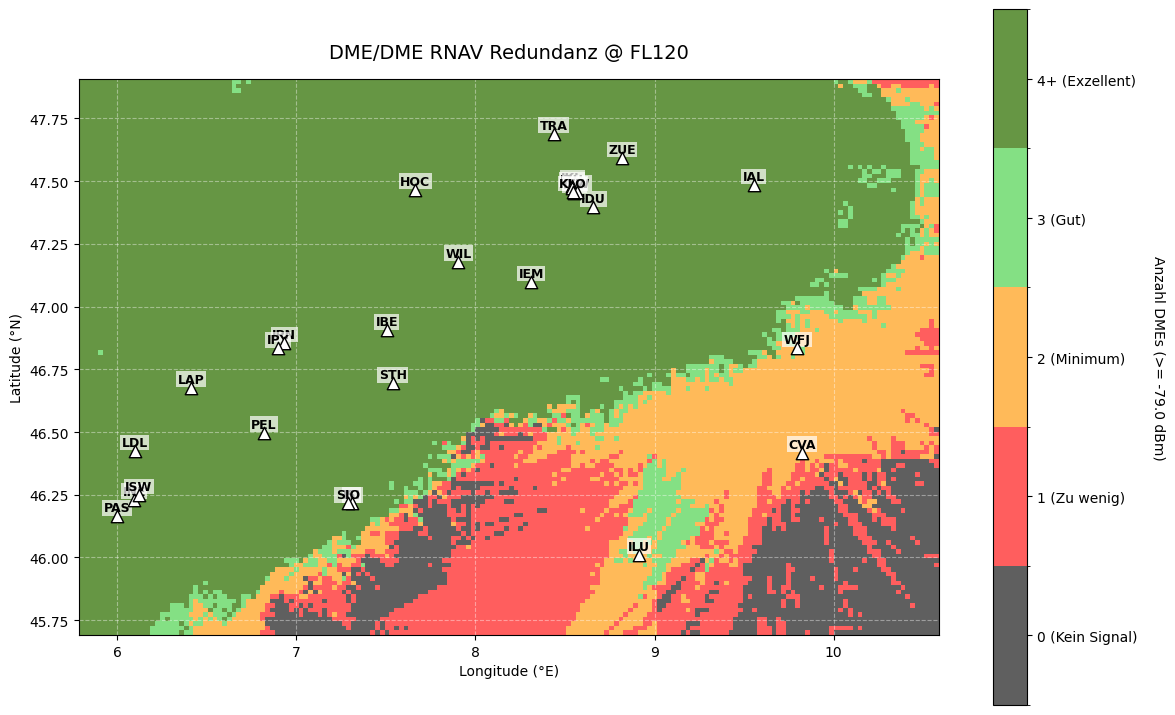

In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def plot_final_coverage(dme_df, grid_points, counts, fl_label=f"FL{FLIGHTLEVEL}"):
    # 1. Reshape the flat counts into a 2D grid
    # We find how many unique lats and lons were in our grid
    lons = np.unique(grid_points[:, 4])
    lats = np.unique(grid_points[:, 3])
    Z = counts.reshape(len(lats), len(lons))
    
    # 2. Define the discrete Color Map matching your screenshot
    # Colors: Dark Grey, Red, Orange, Light Green, Dark Green
    colors = ['#4d4d4d', '#ff4c4c', '#ffb347', '#77dd77', '#558b2f']
    cmap = mcolors.ListedColormap(colors)
    # Boundaries: 0, 1, 2, 3, 4, and "more"
    bounds = [0, 1, 2, 3, 4, 10] 
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    fig, ax = plt.subplots(figsize=(12, 9))

    # 3. Create the heatmap
    # We use pcolormesh for better alignment with geographic grids
    mesh = ax.pcolormesh(lons, lats, Z, cmap=cmap, norm=norm, shading='auto', alpha=0.9)

    # 4. Plot DME Stations with Labels
    for _, dme in dme_df.iterrows():
        # Plot triangle
        ax.scatter(dme['lon'], dme['lat'], marker='^', color='white', 
                   edgecolors='black', s=80, zorder=5)
        # Add Label (IDENT)
        ax.text(dme['lon'], dme['lat'] + 0.02, dme['IDENT'], 
                fontsize=9, fontweight='bold', ha='center', 
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    # 5. Customize the Colorbar
    cbar = fig.colorbar(mesh, ax=ax, ticks=[0.5, 1.5, 2.5, 3.5, 7], shrink=0.8)
    cbar.ax.set_yticklabels([
        '0 (Kein Signal)', 
        '1 (Zu wenig)', 
        '2 (Minimum)', 
        '3 (Gut)', 
        '4+ (Exzellent)'
    ])
    cbar.set_label(f'Anzahl DMEs (>= -79.0 dBm)', rotation=270, labelpad=20)

    # 6. Formatting
    ax.set_title(f"DME/DME RNAV Redundanz @ {fl_label}", fontsize=14, pad=15)
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")
    ax.grid(True, linestyle='--', alpha=0.4, color='white')
    
    # Set a nice aspect ratio for Switzerland
    ax.set_aspect(1.4) 
    
    plt.tight_layout()
    plt.show()

# To call it:
plot_final_coverage(dme_ecef, grid_ecef, coverage_counts, fl_label=f"FL{FLIGHTLEVEL}")



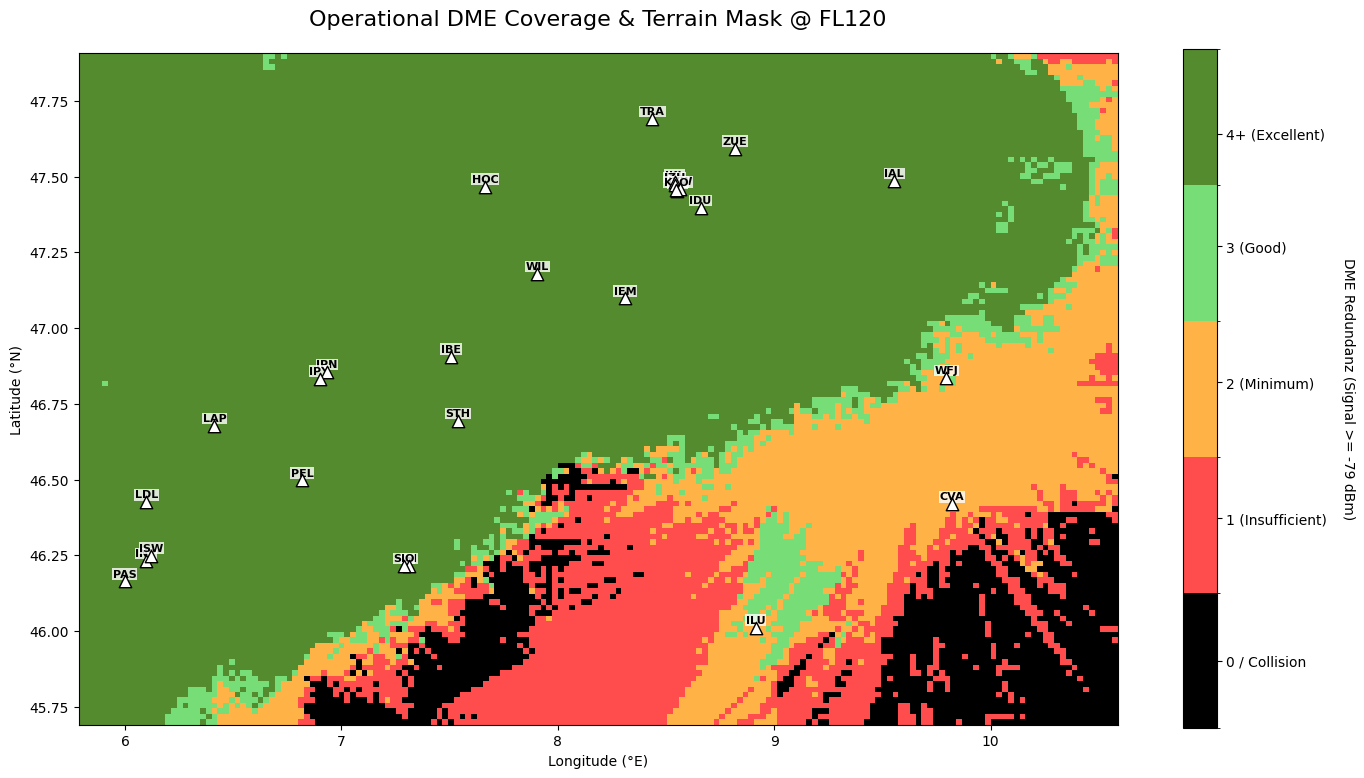

In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import geopandas as gpd

def plot_combined_coverage(dme_df, grid_points, counts, collision_mask, fl_label=""):
    # 1. Reshape data
    lons = np.unique(grid_points[:, 4])
    lats = np.unique(grid_points[:, 3])
    Z = counts.reshape(len(lats), len(lons)).astype(float)
    M = collision_mask.reshape(len(lats), len(lons))
    
    # 2. Mask the Z data: Set to 0 if there is a collision
    # This turns collision areas into the "Black" category
    Z[M == 1] = 0 
    
    # 3. Define the discrete Color Map
    # Index 0: Black (Collision or No Signal)
    # Index 1: Red (1 DME)
    # Index 2: Orange (2 DMEs)
    # Index 3: Light Green (3 DMEs)
    # Index 4: Dark Green (4+ DMEs)
    colors = ['#000000', '#ff4c4c', '#ffb347', '#77dd77', '#558b2f']
    cmap = mcolors.ListedColormap(colors)
    bounds = [0, 0.9, 1.9, 2.9, 3.9, 20] 
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    fig, ax = plt.subplots(figsize=(14, 10), facecolor='white')

    # 4. Create the heatmap
    mesh = ax.pcolormesh(lons, lats, Z, cmap=cmap, norm=norm, shading='auto', alpha=1.0)

    # 5. Add Switzerland Border
    try:
        # Note: If geopandas datasets are missing, load from the web link provided earlier
        world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
        swiss_border = world[world.name == "Switzerland"]
        swiss_border.boundary.plot(ax=ax, color='white', linewidth=1.5, zorder=3, alpha=0.4)
    except:
        pass

    # 6. Plot DME Stations
    for _, dme in dme_df.iterrows():
        ax.scatter(dme['lon'], dme['lat'], marker='^', color='white', 
                   edgecolors='black', s=80, zorder=5)
        ax.text(dme['lon'], dme['lat'] + 0.015, dme['IDENT'], 
                fontsize=8, fontweight='bold', ha='center', 
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=0.5))

    # 7. Customize Colorbar
    cbar = fig.colorbar(mesh, ax=ax, ticks=[0.45, 1.45, 2.45, 3.45, 10], shrink=0.7)
    cbar.ax.set_yticklabels([
        '0 / Collision', 
        '1 (Insufficient)', 
        '2 (Minimum)', 
        '3 (Good)', 
        '4+ (Excellent)'
    ])
    cbar.set_label(f'DME Redundanz (Signal >= {P_RX_THRESHOLD} dBm)', rotation=270, labelpad=20)

    # Formatting
    ax.set_title(f"Operational DME Coverage & Terrain Mask @ FL{FLIGHTLEVEL}", fontsize=16, pad=20)
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")
    ax.set_facecolor('#000000') # Dark background for area outside grid
    ax.set_aspect(1.4) 
    
    plt.tight_layout()
    plt.show()

# Execution:
plot_combined_coverage(dme_ecef, grid_ecef, coverage_counts, collision_mask, fl_label=f"FL{FLIGHTLEVEL}")